In [54]:
##  Impprt Libraries
## In this section we import the required Python libraries for data manipulation, analysis and visualisation.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import time
import matplotlib.ticker as ticker

sns.set_style("whitegrid")

In [2]:
## Load Dataset
## Display the first rows
sales_data = pd.read_csv("Superstore.csv")
sales_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
## Exploratory Data Analysis (EDA)

In [4]:
print("Dataset Shape: ", sales_data.shape) # number of rows and colums
print("ColumnsNam:", sales_data.columns)   # name of columns

Dataset Shape:  (9800, 18)
ColumnsNam: Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [5]:
sales_data.dtypes # check the data type

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [6]:
sales_data.describe() # summary statstics for numerical columns

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [7]:
for col in ['Order Date', 'Ship Date']: #define the date columns as datetime columns instead of objects 
    sales_data[col] = pd.to_datetime(sales_data[col], dayfirst=True) # dayfirst is to read the date in euorpean format dd.mm.yy

In [8]:
sales_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [9]:
sales_data.isnull().sum() #check missing value in each column

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [10]:
sales_data["Postal Code"]= sales_data["Postal Code"] .fillna("Unknown") # Handling the missing Postal codes

In [11]:
sales_data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [12]:
sales_data.duplicated().sum() # Check Duplicates

np.int64(0)

In [13]:
sales_data.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code              object
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

In [14]:
## Feature Engineering 
# Extract year, month and quarter from order date
sales_data["Year"]= sales_data["Order Date"].dt.year
sales_data["Month"]= sales_data["Order Date"].dt.month
sales_data["Quartetr"]= sales_data["Order Date"].dt.quarter

In [15]:
sales_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Quartetr
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,4
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,4
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,2
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,4
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,4


In [16]:
sales_data['City'].value_counts() # the cities orders numbers

City
New York City    891
Los Angeles      728
Philadelphia     532
San Francisco    500
Seattle          426
                ... 
Goldsboro          1
Montebello         1
Abilene            1
Normal             1
Springdale         1
Name: count, Length: 529, dtype: int64

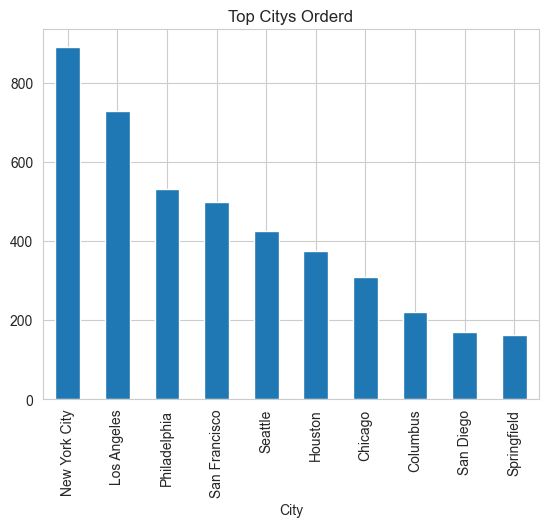

In [55]:
# visualization of The cities with the highest order rate
sales_data['City'].value_counts() \
.head(10) \
.plot(kind='bar', title='Top Citys Orderd')
plt.savefig("images/top_citys_order.png")

In [18]:
sales_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Quartetr
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,4
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,4
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,2
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,4
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,4


In [19]:
## Total Sales
total_sales= sales_data["Sales"].sum()
print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,261,536.78


In [20]:
# Total Orders
total_orders= sales_data.shape[0]
print(f"Total Orders: {total_orders}")

Total Orders: 9800


In [21]:
# Average Sale per Order
avg_sales= sales_data["Sales"].mean()
print(f"Avrage Sales per Order: ${avg_sales:,.2f}")

Avrage Sales per Order: $230.77


In [22]:
## Sales by Category, Sub-Category and Region
ca_sale= sales_data.groupby("Category")["Sales"].sum().sort_values(ascending=False)
subca_sale= sales_data.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
reg_sale= sales_data.groupby("Region")["Sales"].sum().sort_values(ascending=False)

In [23]:
ca_sale

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

C:\Users\yaras\AppData\Local\Temp\ipykernel_6032\1116882087.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ca_sale.index, y=ca_sale.values, palette="viridis")


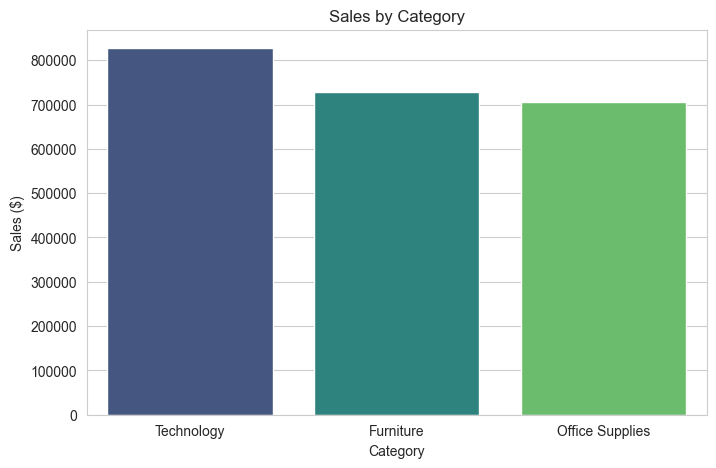

In [61]:
plt.figure(figsize=(8,5))
sns.barplot(x=ca_sale.index, y=ca_sale.values, palette="viridis")
plt.title("Sales by Category")
plt.ylabel("Sales ($)")
plt.xlabel("Category")

plt.savefig("images/sales_by_category.png", bbox_inches="tight")
plt.show()

In [25]:
subca_sale

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

C:\Users\yaras\AppData\Local\Temp\ipykernel_6032\3668837169.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subca_sale.index, y=subca_sale.values, palette="magma")


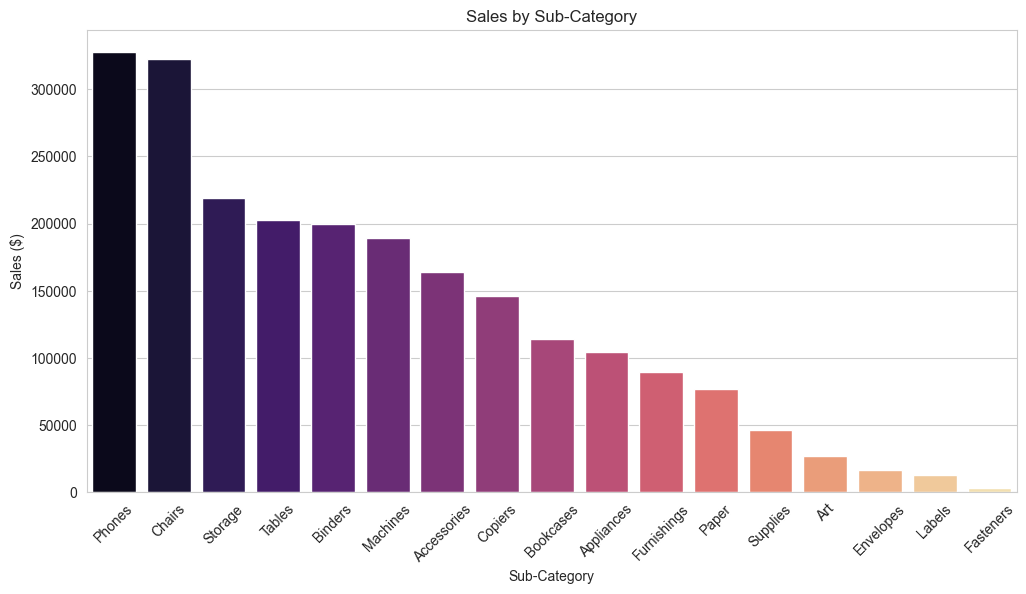

In [62]:
plt.figure(figsize=(12,6))
sns.barplot(x=subca_sale.index, y=subca_sale.values, palette="magma")
plt.title("Sales by Sub-Category")
plt.ylabel("Sales ($)")
plt.xlabel("Sub-Category")
plt.xticks(rotation=45)  # Rotate x-axis labels to read easily

plt.savefig("images/sales_by_subcategory.png", bbox_inches="tight")
plt.show()

In [27]:
reg_sale

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

C:\Users\yaras\AppData\Local\Temp\ipykernel_6032\2376123231.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reg_sale.index, y=reg_sale.values, palette="coolwarm")


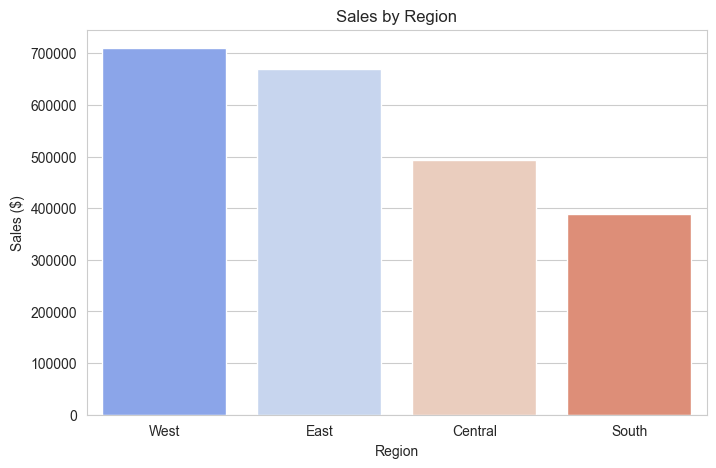

In [63]:
plt.figure(figsize=(8,5))
sns.barplot(x=reg_sale.index, y=reg_sale.values, palette="coolwarm")
plt.title("Sales by Region")
plt.ylabel("Sales ($)")
plt.xlabel("Region")

plt.savefig("images/sales_by_region.png", bbox_inches="tight")
plt.show()

In [29]:
## Top Selling Products
pro_sale= sales_data.groupby("Product Name")["Sales"].sum().sort_values(ascending=False)
top_10_Products= pro_sale.head(10)
top_10_Products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

C:\Users\yaras\AppData\Local\Temp\ipykernel_6032\1269120864.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_Products.values, y=top_10_Products.index, palette="spring")


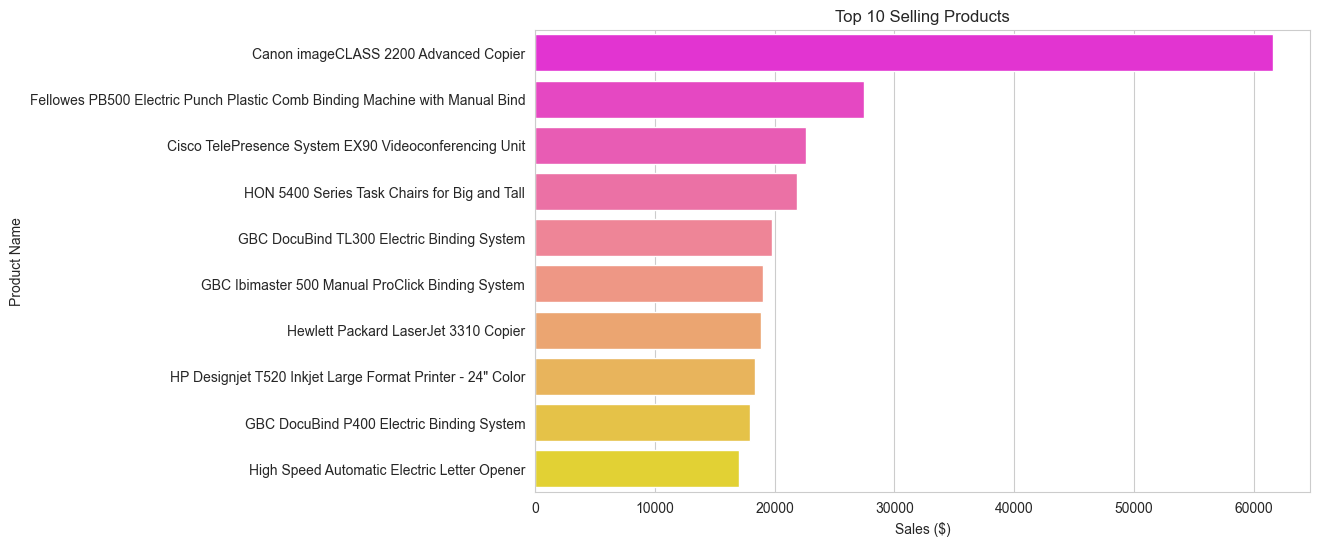

In [64]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_10_Products.values, y=top_10_Products.index, palette="spring")
plt.title("Top 10 Selling Products")
plt.xlabel("Sales ($)")
plt.ylabel("Product Name")

plt.savefig("images/top_10_selling_products.png", bbox_inches="tight")
plt.show()

In [31]:
## Least Selling Products
least_selling = (
    sales_data.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=True)
    .head(10)
)

least_selling

Product Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Acme Serrated Blade Letter Opener                                   7.632
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Xerox 1989                                                          7.968
4009 Highlighters                                                   8.040
Stockwell Gold Paper Clips                                          8.096
Name: Sales, dtype: float64

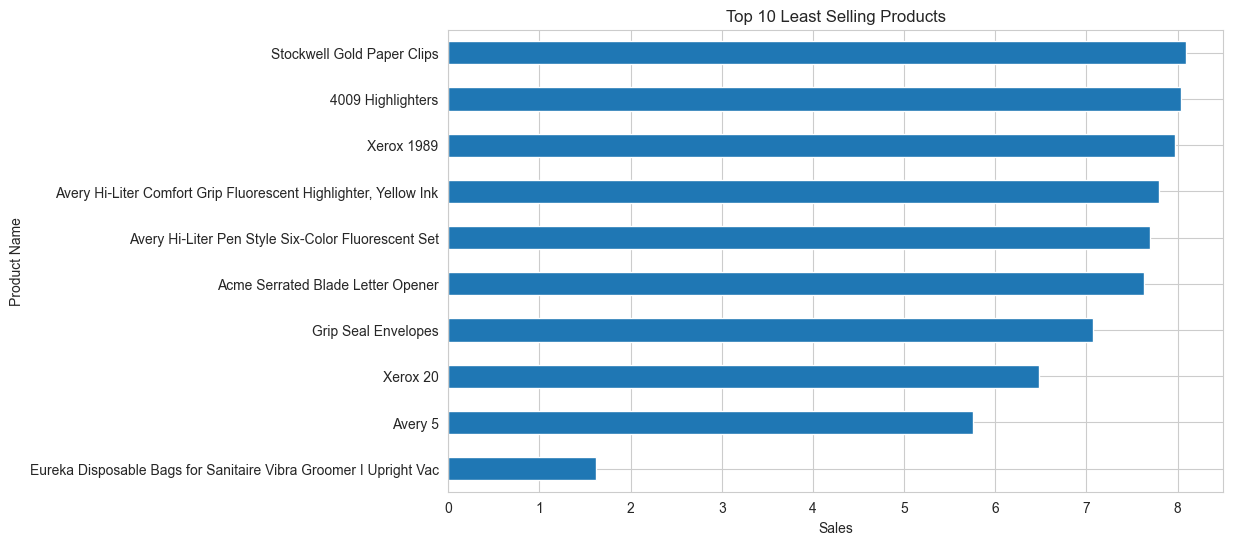

In [65]:
plt.figure(figsize=(10,6))

least_selling.plot(kind="barh")

plt.title("Top 10 Least Selling Products")
plt.xlabel("Sales")
plt.ylabel("Product Name")
plt.savefig("images/top_10_least_selling_products.png", bbox_inches="tight")

plt.show()

In [33]:
# TOP-10 Customers
top_customers = (
    sales_data.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

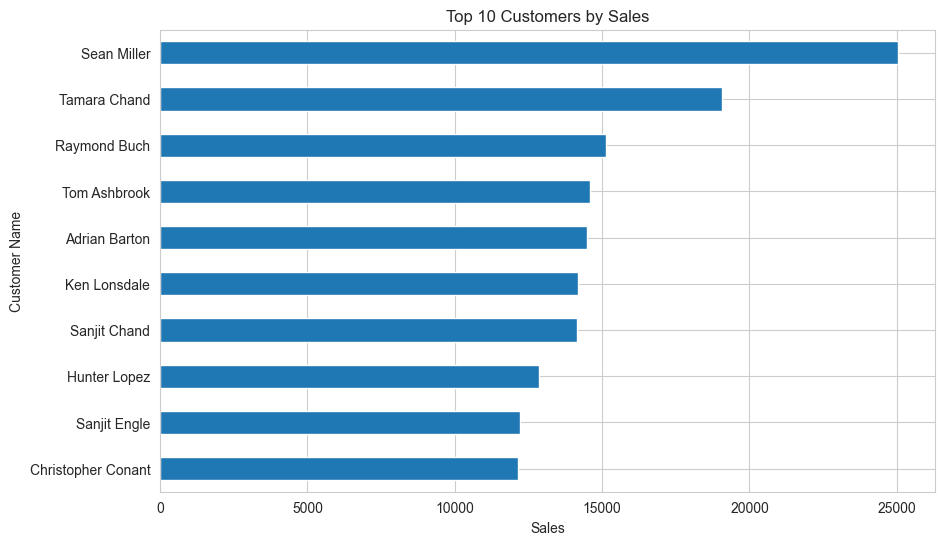

In [66]:
plt.figure(figsize=(10,6))
top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer Name")
plt.savefig("images/top_10_customers.png", bbox_inches="tight")
plt.show()

In [35]:
# Customer Segment Percentage
segment_counts= sales_data["Segment"].value_counts()
segment_counts

Segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64

In [36]:
segment_percentage= sales_data["Segment"].value_counts(normalize=True) * 100
segment_percentage

Segment
Consumer       52.051020
Corporate      30.132653
Home Office    17.816327
Name: proportion, dtype: float64

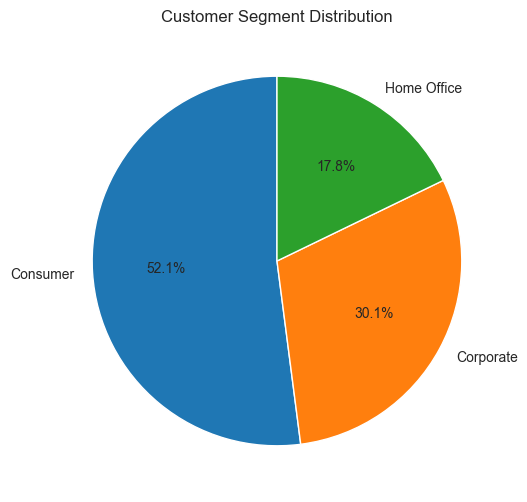

In [67]:
plt.figure(figsize=(6,6))

segment_percentage.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Segment Distribution")
plt.ylabel("")
plt.savefig("images/customer_segment_distribution.png")
plt.show()

In [38]:
### Project Summary

This sales analysis project examined the Superstore dataset to identify key business insights.
 Main findings:
- Calculated total sales and total number of orders
- Identified average sales per order
- Analyzed sales by category, sub-category, and region
- Determined the top 10 selling products & top 10 least selling products
- Identify top cutomers and customers segment distribution
- Created visualizations to support business insights

##This analysis helps understand revenue distribution, top-performing products, and regional performance. These insights can support data-driven business decisions.

In [39]:
sales_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Quartetr
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,4
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,4
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,2
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,4
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,4


In [40]:
## Monthly Sales Trend
#Analyse total sales per month

In [41]:
month_sales= sales_data.groupby(["Year", "Month"])["Sales"].sum().reset_index()
month_sales #monthly sales trend

,Year,Month,Sales
0,2015,1,14205.7070
1,2015,2,4519.8920
2,2015,3,55205.7970
3,2015,4,27906.8550
4,2015,5,23644.3030
5,2015,6,34322.9356
6,2015,7,33781.5430
7,2015,8,27117.5365
8,2015,9,81623.5268
9,2015,10,31453.3930


In [42]:
month_sales["Date"]= pd.to_datetime(month_sales[["Year", "Month"]].assign(Day=1)) # Create a Date column
month_sales

,Year,Month,Sales,Date
0,2015,1,14205.7070,2015-01-01
1,2015,2,4519.8920,2015-02-01
2,2015,3,55205.7970,2015-03-01
3,2015,4,27906.8550,2015-04-01
4,2015,5,23644.3030,2015-05-01
5,2015,6,34322.9356,2015-06-01
6,2015,7,33781.5430,2015-07-01
7,2015,8,27117.5365,2015-08-01
8,2015,9,81623.5268,2015-09-01
9,2015,10,31453.3930,2015-10-01


In [43]:
month_sales= month_sales.sort_values("Date") # sort by data

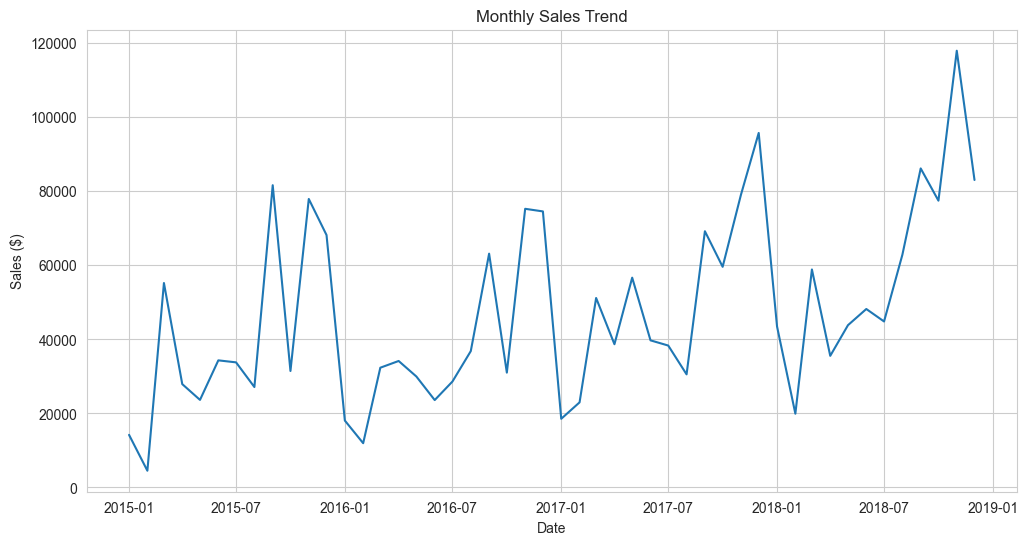

In [68]:
# Plot Monthly Sales Trend
plt.figure(figsize=(12,6))
plt.plot(month_sales["Date"], month_sales["Sales"])
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.savefig("images/monthly_sales_trend.png", bbox_inches="tight")
plt.show()

In [45]:
## correlation between Sales numbers and months
pivot_sales= sales_data.pivot_table(
    values= "Sales",
    index= "Year",
    columns= "Month",
    aggfunc= "sum"
)
pivot_sales

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2015,14205.7070,4519.8920,55205.7970,27906.8550,23644.3030,34322.9356,33781.543,27117.5365,81623.5268,31453.3930,77907.6607,68167.0585
2016,18066.9576,11951.4110,32339.3184,34154.4685,29959.5305,23599.3740,28608.259,36818.3422,63133.6060,31011.7375,75249.3995,74543.6012
2017,18542.4910,22978.8150,51165.0590,38679.7670,56656.9080,39724.4860,38320.783,30542.2003,69193.3909,59583.0330,79066.4958,95739.1210
2018,43476.4740,19920.9974,58863.4128,35541.9101,43825.9822,48190.7277,44825.104,62837.8480,86152.8880,77448.1312,117938.1550,83030.3888


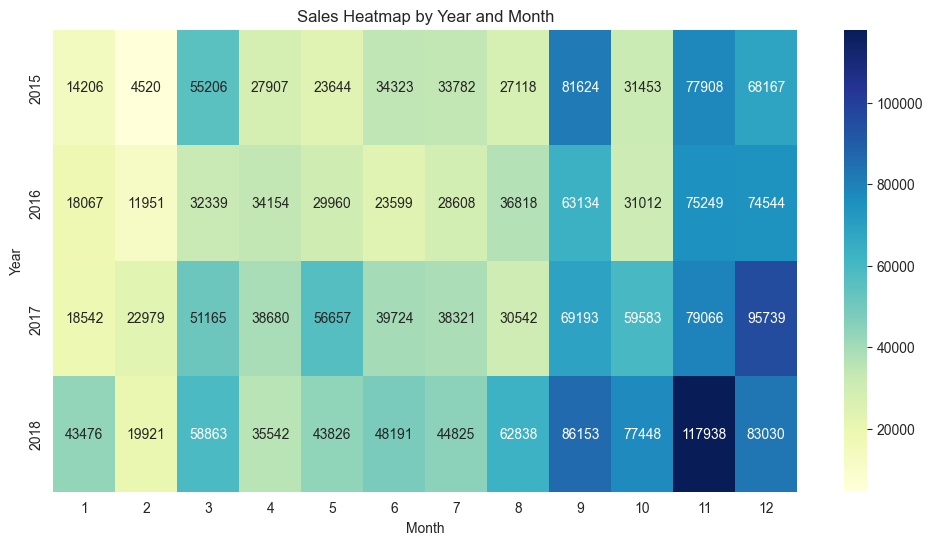

In [69]:
## this heatmap shows sales distribution across months and years to identify seasonal trends and busiest periods.
plt.figure(figsize=(12,6))
sns.heatmap(pivot_sales, annot=True, fmt=".0f", cmap="YlGnBu")

plt.title("Sales Heatmap by Year and Month")
plt.xlabel("Month")
plt.ylabel("Year")

plt.savefig("images/sales_heatmap_by_year_and_month.png", bbox_inches="tight")
plt.show()

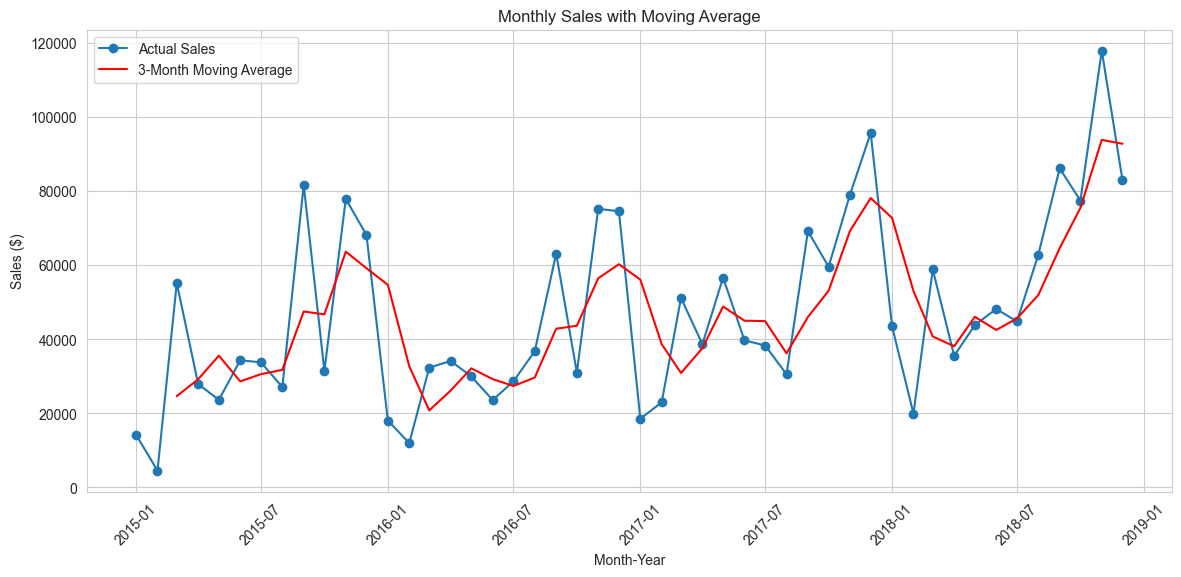

In [70]:
## Moving Average
month_sales["MA_3"]= month_sales["Sales"].rolling(window=3).mean()
plt.figure(figsize=(14,6))
plt.plot(month_sales["Date"], month_sales["Sales"], label="Actual Sales", marker="o")
plt.plot(month_sales["Date"], month_sales["MA_3"], label="3-Month Moving Average", color="red")
plt.title("Monthly Sales with Moving Average")
plt.xlabel("Month-Year")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)
plt.legend()

plt.savefig("images/monthly_sales_with_moving_average.png")
plt.show()

In [48]:
## Linear Regression Forecast
from sklearn.linear_model import LinearRegression
month_sales["Date_Ordinal"]= month_sales["Date"].map(lambda date: date.toordinal()) # convert Date to ordinal (number)

# Feature (X) and target (y)
X= month_sales[["Date_Ordinal"]] # independent variable
y= month_sales["Sales"] # dependent variable

In [49]:
# Train Linear Regression model
model= LinearRegression()
model.fit(X, y)

LinearRegression()

In [50]:
# Predict sales
month_sales["Predicted"]= model.predict(X)

In [51]:
month_sales

,Year,Month,Sales,Date,MA_3,Date_Ordinal,Predicted
0,2015,1,14205.7070,2015-01-01,NaN,735599,26263.988250
1,2015,2,4519.8920,2015-02-01,NaN,735630,27168.402222
2,2015,3,55205.7970,2015-03-01,24643.798667,735658,27985.292262
3,2015,4,27906.8550,2015-04-01,29210.848000,735689,28889.706235
4,2015,5,23644.3030,2015-05-01,35585.651667,735719,29764.945563
5,2015,6,34322.9356,2015-06-01,28624.697867,735750,30669.359536
6,2015,7,33781.5430,2015-07-01,30582.927200,735780,31544.598865
7,2015,8,27117.5365,2015-08-01,31740.671700,735811,32449.012837
8,2015,9,81623.5268,2015-09-01,47507.535433,735842,33353.426810
9,2015,10,31453.3930,2015-10-01,46731.485433,735872,34228.666138


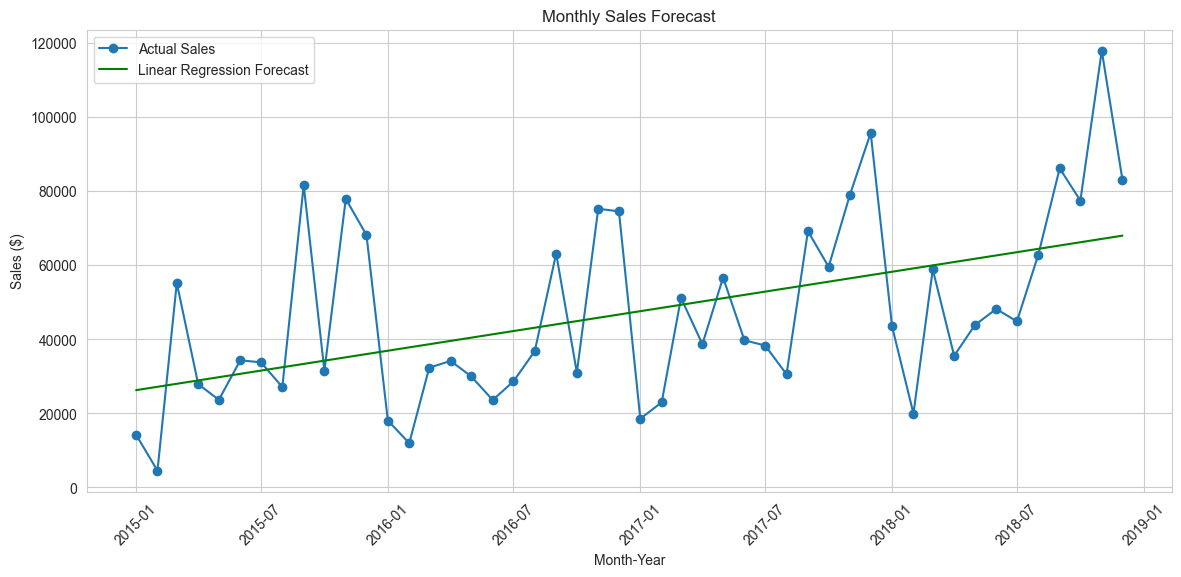

In [71]:
# Plot actual vs predicted
plt.figure(figsize=(14,6))
plt.plot(month_sales["Date"], month_sales["Sales"], label="Actual Sales", marker="o") 
plt.plot(month_sales["Date"], month_sales["Predicted"], label="Linear Regression Forecast", color="green")
plt.title("Monthly Sales Forecast")
plt.xlabel("Month-Year")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)
plt.legend()

plt.savefig("images/monthly_sales_forecast.png")
plt.show()

In [53]:
## Business Insights

- Total sales reached approximately 2.26 million, indicating strong overall performance.
- Sales increased toward the last quarter of the year, showing seasonal demand.
- Monthly heatmap analysis confirmed that Q4 is the busiest period.
- Technology category generated the highest sales compared to other categories.
- The West and Central regions contributed significantly to overall revenue.
- Top customers were identified, showing that a small group contributes a large share of sales.
- Customer segment analysis showed that the Consumer segment represents the majority of customers, followed by Corporate and Home Office.
- Top-selling products were highlighted to identify high-demand items.
- Least-selling products were identified, which may require marketing focus or review.
- Moving average and linear regression were applied to analyze sales trends and provide a simple forecast.